# Actividad 3

Equipo: Panditas Panaderos

## Integrantes
- Emilio Eduardo Garza RIvera - 2976048
- Adrián Alonso Jair Morales Márquez - 3110244
- Miguel Omar Muñoz Solis - 2953688
- Artur Emmanuel Martínez Martínez - 3098530
- Leonardo Yahir Martínez Estrada - 07000080

## Slogan
"A hornear"

In [46]:
%pip install scikit-learn pandas

Note: you may need to restart the kernel to use updated packages.


# Paso 1: Elección del dataset

Se seleccionará el dataset de Breast Cancer recuperado del siguiente enlace: *https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html*

# Paso 2: Información del dataset

* **Nombre:** *Breast Cancer*
* **Fuente:** *scikit-learn developers. (s.f.). load_breast_cancer.*
* **Liga de acceso:** *https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html*

**Contexto**
Para esta actividad se aplicará un modelo de máquina de soporte vectorial y una técnica de agrupamiento sobre un mismo conjunto de datos con el propósito de:
- comparar las preguntas que responde cada enfoque
- evaluar sus resultados
- interpretar los patrones identificados mediante visualizaciones y métricas pertinentes

*Cada registro representa una muestra de tejido mamario obtenida mendiante una aspiración con aguja fina de una masa sospechosa en un paciente.*

*La variable objetivo es la clasificación del tumor. Indica si la masa es benigna o maligna basándose en el análisis de las células.*

*Las variables predictoras contienen características numéricas calculadas a partir de una imagen digitalizada de la muestra de tejido. Incluyen medidas de los núcleos celulares presentes en la imagen, como el radio, la textura, el perímetro, el área, la suavidad, la compacidad, la concavidad, entre otros.*

**Pregunta para el análisis supervisado**
*¿Se puede predecir con alta precisión si un tumor es benigno o maligno basándose únicamente en las características morfométricas de sus núcleos celulares?*

**Pregunta para el análisis no supervisado**
*¿Existen agrupaciones naturales en los datos que separen las muestras con características de tumores malignos de los benignos sin necesidad de conocer su etiqueta real previamente?*

# Paso 3: Revisión inicial de la estructura

In [47]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

A diferencia de las actividades anteriores donde teníamos la variable objetivo dentro del dataframe, ahora el **dataframe** sólo incluye las **variables predictoras**, mientras que el **data** sí incluye toda la información. Para esta actividad estaremos trabajando con los 2 formatos para realizar una exploración más precisa.

In [48]:
print("\nEstructura del Dataset Breast Cancer:\n")

# Número de registros
print("Número de registros:", df.shape[0])

# Número de variables
print("Número de variables:", df.shape[1])

# Variables disponibles
print("Variables disponibles:", df.columns.tolist())

# Tipos de datos de cada variable
print("\nTipos de datos de cada variable:\n", df.dtypes)


Estructura del Dataset Breast Cancer:

Número de registros: 569
Número de variables: 30
Variables disponibles: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Tipos de datos de cada variable:
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float

In [49]:
# Presencia de valores faltantes
print("\nPresencia de valores faltantes:\n", df.isnull().sum())


Presencia de valores faltantes:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [50]:
# Posibles duplicados
print("\nNúmero de registros duplicados:", df.duplicated().sum())


Número de registros duplicados: 0


En los resultados podemos ver que el dataset está compuesto por 569 registros y 30 variables numéricas predictoras, todas de tipo float64. Asimismo, confirmamos que no existen valores nulos ni registros duplicados. Por esta razón, no es necesario aplicar técnicas de imputación, eliminación de filas ni conversiones de tipo de datos.

In [51]:
# Distribución de la variable objetivo
print("\nDistribución de la variable objetivo:\n")
print(pd.Series(data.target).value_counts())

print("\nDistribución de la variable objetivo (nombres):\n")
target_names = pd.Series(data.target).map({
  0: data.target_names[0],
  1: data.target_names[1]
})
print(target_names.value_counts())

print("\nDistribución de la variable objetivo (porcentaje):\n")
print(target_names.value_counts(normalize=True) * 100)


Distribución de la variable objetivo:

1    357
0    212
Name: count, dtype: int64

Distribución de la variable objetivo (nombres):

benign       357
malignant    212
Name: count, dtype: int64

Distribución de la variable objetivo (porcentaje):

benign       62.741652
malignant    37.258348
Name: proportion, dtype: float64


Para que quizá sea un poco más fácil la exploración de la variable objetivo, ésta la podemos agregar a una copia del dataset.

In [52]:
df_target = df.copy()
df_target['target'] = data.target

df_target['target_name'] = pd.Categorical.from_codes(data.target, data.target_names)

print(df_target.head(25))

print("\nDistribución de la variable objetivo (nombres) con el DataFrame:\n")
print(df_target['target_name'].value_counts())

    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.990         10.38          122.80     1001.0          0.11840   
1        20.570         17.77          132.90     1326.0          0.08474   
2        19.690         21.25          130.00     1203.0          0.10960   
3        11.420         20.38           77.58      386.1          0.14250   
4        20.290         14.34          135.10     1297.0          0.10030   
5        12.450         15.70           82.57      477.1          0.12780   
6        18.250         19.98          119.60     1040.0          0.09463   
7        13.710         20.83           90.20      577.9          0.11890   
8        13.000         21.82           87.50      519.8          0.12730   
9        12.460         24.04           83.97      475.9          0.11860   
10       16.020         23.24          102.70      797.8          0.08206   
11       15.780         17.89          103.60      781.0          0.09710   

# Paso 4: Selección de variables numericas a utilizar

In [53]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Selección de predictoras (X) y separación de la variable objetivo (y)
X = df.copy() 
y = data.target

# Aplicar escalamiento
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

print("Datos escalados exitosamente.")
display(X_scaled.head())

Datos escalados exitosamente.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


¿Por qué SVM y K-Means se ven afectados por las diferencias de escala?

Básicamente, los dos modelos hacen su trabajo midiendo distancias entre los datos. Por eso, si los números están en escalas muy diferentes, los cálculos se descuadran.

Lo que pasa en K-Means (No Supervisado): Este modelo arma los grupos viendo qué tan cerca están los datos unos de otros. El problema es que si tenemos una variable como el "área" que maneja números de miles, y otra como la "suavidad" que son puros decimales, el algoritmo se va a guiar casi por completo por los números grandes y va a ignorar los pequeños. Escalar los datos sirve para emparejar y que todas las variables pesen lo mismo.

Lo que pasa en SVM (Supervisado): Este algoritmo trata de trazar la mejor línea posible para separar los tipos. Como también se basa en distancias, si no escalamos los datos, la línea se va a deformar dándole preferencia a las variables más grandes. Al usar la herramienta de escalamiento (StandardScaler), ponemos todos los números en una misma proporción; esto evita que el modelo se confunda y le ayuda a encontrar esa separación de forma más rápida y precisa.

# Paso 5: ANÁLISIS SUPERVISADO

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Total de registros para entrenar: {X_train.shape[0]}")
print(f"Total de registros para probar: {X_test.shape[0]}")

Total de registros para entrenar: 455
Total de registros para probar: 114


¿Por qué dividir los datos nos permite evaluar el modelo con datos no vistos?

Básicamente, hacemos esta división para que el modelo no se aprenda los resultados de memoria.

Lo que pasa con el grupo de entrenamiento (80%): Le damos la mayor parte de los datos al modelo para que los revise, vea las respuestas reales y aprenda a diferenciar los tipos de tumores.

Lo que pasa con el grupo de prueba (20%): Estos son los datos "no vistos". Los separamos desde el principio y se los ocultamos al modelo. El problema es que, si lo evaluamos con los mismos datos que ya estudió, el modelo va a acertar todo. Al ponerlo a prueba con este 20% que nunca ha visto, comprobamos si de verdad aprendió a identificar los patrones. Así estamos seguros de que funcionará bien cuando analice muestras de pacientes totalmente nuevos.

# Paso 6: Entreamiento de modelos y resultados

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Preparamos el primer modelo con kernel lineal
svm_lineal = SVC(kernel='linear', random_state=42)

# Preparamos el segundo modelo con kernel RBF
svm_rbf = SVC(kernel='rbf', random_state=42)

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Volvemos a dividir los datos originales sin escalar (X)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


pipeline_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_lineal)
])

pipeline_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_rbf)
])


pipeline_lineal.fit(X_train_raw, y_train)
pipeline_rbf.fit(X_train_raw, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hacemos las predicciones con los datos de prueba
y_pred_lineal = pipeline_lineal.predict(X_test_raw)
y_pred_rbf = pipeline_rbf.predict(X_test_raw)

# Función para calcular todas las calificaciones
def calcular_metricas(y_real, y_pred):
    return [
        round(accuracy_score(y_real, y_pred), 4),
        round(precision_score(y_real, y_pred), 4),
        round(recall_score(y_real, y_pred), 4),
        round(f1_score(y_real, y_pred), 4)
    ]

resultados_lineal = calcular_metricas(y_test, y_pred_lineal)
resultados_rbf = calcular_metricas(y_test, y_pred_rbf)

In [58]:
import pandas as pd

# Tabla de resultados
tabla_resultados = pd.DataFrame({
    'Modelo SVM': ['Modelo 1', 'Modelo 2'],
    'Kernel': ['Lineal', 'RBF o polinomial'],
    'Accuracy': [resultados_lineal[0], resultados_rbf[0]],
    'Precision': [resultados_lineal[1], resultados_rbf[1]],
    'Recall': [resultados_lineal[2], resultados_rbf[2]],
    'F1-score': [resultados_lineal[3], resultados_rbf[3]]
})

display(tabla_resultados)

,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9737,0.9859,0.9722,0.9790
1,Modelo 2,RBF o polinomial,0.9825,0.9861,0.9861,0.9861


# Paso 7:

Modelo con mejor desempeño: SVM con kernel RBF


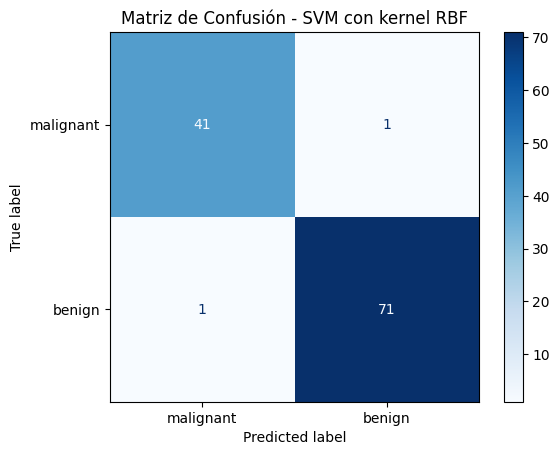

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Elegimos el modelo con mejor desempeño según la tabla de resultados
# (ajusta esto según cuál haya dado mejor accuracy/f1 en tu caso)
if resultados_rbf[0] >= resultados_lineal[0]:
    mejor_modelo = "SVM con kernel RBF"
    y_pred_mejor = y_pred_rbf
else:
    mejor_modelo = "SVM con kernel Lineal"
    y_pred_mejor = y_pred_lineal

print(f"Modelo con mejor desempeño: {mejor_modelo}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title(f"Matriz de Confusión - {mejor_modelo}")
plt.show()

El modelo con mejor desempeño fue el svm con kernel RBF, alcanzando un resultado casi perfecto sobre el conjunto de prueba (144 casos)

Verdaderos malignos:41 - tumores malignos correctamente identificados

Falsos negativos:1 - un tumor realmente maligno que el modelo clasificó como benigno. Este es el error más crítico en un contexto médico, ya queimplicaría que a una paciente con cáncer no se le detecta a tiempo

Falsos positivos:1 - un tumoer realmente benigno que el modelo clasificó como maligno. Es un error menos grave, ya que en la práctica solo generaría estudios adicionales innecesarios

Verdaderos benignos:71 - casos benignos correctamente identificados

El modelo se equivocó en solo 2 de los 114 casos (1 error por cada clase), lo que indica un desempeño equilibrado: no hay una clase que le resulte claramente más dificil de distinguir que la otra

¿Por qué no basta con revisar únicamente el accuracy?

El accuracy por sí solo puede ser engañoso, especialmente en datasets desbalanceados. Si, por ejemplo, el 90% de los casos en el dataset fueran benignos, un modelo que simplemente predijiera "benigno" en todos los casos alcanzaría un 90% de accuracy sin haber aprendido realmente a distinguir tumeros malignos

La matriz de confusión permite ver el desglose real de los aciertos y errores por clase. En este caso, confirma que el modelo no solo tiene un accuracy alto, sino que además identifica correctamente casi todos los casos malignos (41 de 42), que es precisamente la clase que más importa detectar bien en un contexto de diagnóstico médico

# Paso 8:

In [60]:
# Comparamos dos valores distintos de C para el kernel RBF
svm_rbf_c_bajo = SVC(kernel='rbf', C=0.1, random_state=42)
svm_rbf_c_alto = SVC(kernel='rbf', C=10, random_state=42)

pipeline_c_bajo = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_rbf_c_bajo)
])

pipeline_c_alto = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_rbf_c_alto)
])

pipeline_c_bajo.fit(X_train_raw, y_train)
pipeline_c_alto.fit(X_train_raw, y_train)

y_pred_c_bajo = pipeline_c_bajo.predict(X_test_raw)
y_pred_c_alto = pipeline_c_alto.predict(X_test_raw)

resultados_c_bajo = calcular_metricas(y_test, y_pred_c_bajo)
resultados_c_alto = calcular_metricas(y_test, y_pred_c_alto)

tabla_hiperparametros = pd.DataFrame({
    'Configuración': ['C = 0.1 (bajo)', 'C = 10 (alto)', 'C = 1.0 (default, referencia)'],
    'Accuracy': [resultados_c_bajo[0], resultados_c_alto[0], resultados_rbf[0]],
    'Precision': [resultados_c_bajo[1], resultados_c_alto[1], resultados_rbf[1]],
    'Recall': [resultados_c_bajo[2], resultados_c_alto[2], resultados_rbf[2]],
    'F1-score': [resultados_c_bajo[3], resultados_c_alto[3], resultados_rbf[3]]
})

display(tabla_hiperparametros)

,Configuración,Accuracy,Precision,Recall,F1-score
0,C = 0.1 (bajo),0.9474,0.9459,0.9722,0.9589
1,C = 10 (alto),0.9737,0.9859,0.9722,0.9790
2,"C = 1.0 (default, referencia)",0.9825,0.9861,0.9861,0.9861


C = 0.1 (el mas bajo): obtuvo el peor desempeño de los tres (accuracy 0.9474). Al ser tan permisivo con los errores de entrenamiento, el modelo prioriza un margen ancho por encima de clasificar correctamente todos los casos de entrenamiento. Esto genera una frontera de decisión demasiado simple para este dataset, que termina subjetando (underfitting) - no captura suficientemente bien los patrones que distinguen benigno de maligno

C = 10 (el más alto): mejoró bastante respecto a C = 0.1 (accuracy 0.9737), pero no llegó al nivel del default. Al penalizar fuerte cada error, el modelo ajusta aun frontera más compleja y flexible, pegada a los datos de entrenamiento. Aquí no se ve un sobreajuste severo (los resultados siguen siendo buenos), pero tampoco superó al valor intermedio, lo cual sugiere que ya no hay mucho más que ganar ajustando la frontera más agresivamente, con este set de datos

C = 1.0 (default): fue el punto óptimo entre ambos extremos - econtró un balance entre un margen razzonablemente amplio (buena generalización) y suficiente flexibilidad para clasificar bien los casos de entrenamiento, sin llegar a sobreajustar

El hiperparámetro "C" controla el equilibrio entre margen amplio (mayor generalización, menor riesgo de sobreajuste) y ajuste estricto a los datos de entrenamiento (mayor riesgo de sobreajuste si se sube demasiado).En este dataset, ni el extremo bajo ni el alto superaron al valor intermedio, lo que indica que el balance por default ya estaba bien calibrado para separar tumores benignos y malignos con eeste conjunto de variables

# Paso 9:

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Confirmamos que X_scaled NO incluye la variable objetivo (ya la separamos en el Paso 4)
print("Variables usadas para clustering:", X_scaled.columns.tolist())
print("Número de variables:", X_scaled.shape[1])

Variables usadas para clustering: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Número de variables: 30


In [62]:
inercia = []
silhouette_scores = []
rango_k = range(2, 7)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inercia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"k={k} -> Inercia: {kmeans.inertia_:.2f} | Silhouette Score: {score:.4f}")

k=2 -> Inercia: 11595.53 | Silhouette Score: 0.3434
k=3 -> Inercia: 10061.80 | Silhouette Score: 0.3144
k=4 -> Inercia: 9258.99 | Silhouette Score: 0.2833
k=5 -> Inercia: 8558.66 | Silhouette Score: 0.1582
k=6 -> Inercia: 7970.26 | Silhouette Score: 0.1604


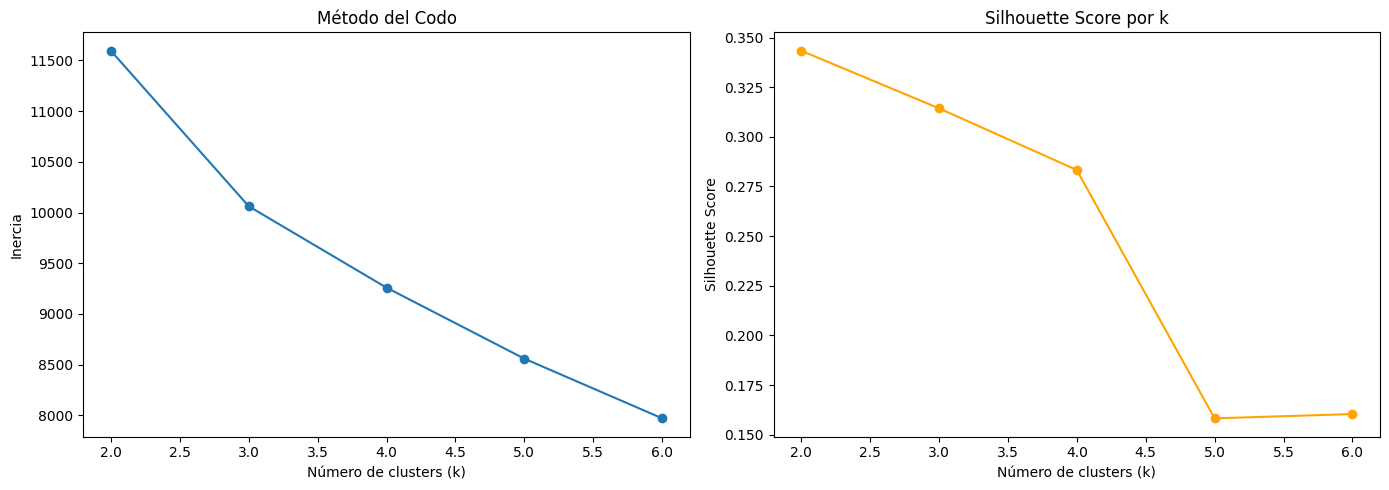

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del codo
axes[0].plot(rango_k, inercia, marker='o')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')

# Gráfico de silhouette score
axes[1].plot(rango_k, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')

plt.tight_layout()
plt.show()

In [64]:
k_optimo = 2 

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df_clusters = X_scaled.copy()
df_clusters['cluster'] = clusters

print(f"\nDistribución de registros por cluster (k={k_optimo}):")
print(df_clusters['cluster'].value_counts())


Distribución de registros por cluster (k=2):
cluster
0    375
1    194
Name: count, dtype: int64


Se evaluaron valores de k entre 2 y 6 utilizando el método del codo y el silhouette score. El silhouette score obtuvo su valor más alto en k=2 (0.3434), disminuyendo de forma progresiva conforme aumenta el número de clusters, con una caída marcada a partir de k=5. El método del codo mostró un decremento gradual y constante de la inercia, sin un punto de quiebre pronunciado que sugiera un valor distinto

Con base en esta evidencia, se seleccionó k=2 como el número óptimo de clusters. Esta decisión también es coherente con la naturaleza del problema: el dataset distingue originalmente entre tumores benignos y malignos, por lo que es razonable que la estructura de los datos, sin utilizar las etiquetas reales, tienda a organizarse en dos grupos naturales. Al aplicar K-Means con k=2, se obtuvieron dos clusters de 375 y 194 registros respectivamente

# Paso 10:

In [65]:

# 1. Asociamos los clusters obtenidos al dataset original sin escalar para interpretar valores reales
df_analisis = X.copy()
df_analisis['cluster'] = clusters

# 2. Seleccionamos las variables morfológicas más representativas
vars_clave = [
    'mean radius', 
    'mean perimeter', 
    'mean area', 
    'mean compactness', 
    'mean concavity', 
    'mean concave points'
]

# 3. Construcción de la tabla resumen con conteo y promedios reales
tabla_resumen = df_analisis.groupby('cluster')[vars_clave].mean().round(2)
tabla_resumen.insert(0, 'Tamaño (N)', df_analisis['cluster'].value_counts())
tabla_resumen.insert(1, '% del Total', (df_analisis['cluster'].value_counts(normalize=True) * 100).round(2))

display(tabla_resumen)

,Tamaño (N),% del Total,mean radius,mean perimeter,mean area,mean compactness,mean concavity,mean concave points
cluster,,,,,,,,
0,375,65.91,12.43,79.82,486.77,0.08,0.04,0.03
1,194,34.09,17.41,115.45,979.86,0.16,0.18,0.09


Descripción de los Grupos

Cluster 0 (Mayoría): Presenta núcleos celulares notablemente pequeños, simétricos y homogéneos, con contornos suaves y regulares.

Cluster 1 (Minoría): Muestra núcleos hipertróficos (mucho más grandes) y con alta deformidad, caracterizados por bordes irregulares, rugosos y marcadas invaginaciones.

Patrones de Diferenciación

Escala y volumen: El factor principal de separación es el tamaño físico (área y radio), el cual llega a duplicarse en el segundo grupo.

Complejidad geométrica: Las células del Cluster 1 presentan un incremento drástico en concavidad y compacidad, rompiendo la forma elíptica natural de una célula sana.

Interpretación Preliminar

El agrupamiento no supervisado separó con éxito los datos según la agresividad del tejido celular sin conocer las etiquetas previas:

Cluster 0  Probables tumores benignos: Conservan una morfología celular estable y poco alterada.

Cluster 1  Probables tumores malignos: Manifiestan la atipia estructural y el crecimiento celular acelerado característicos del cáncer.

# Paso 11:

Varianza explicada - PC1: 44.27% | PC2: 18.97% | Total: 63.24%


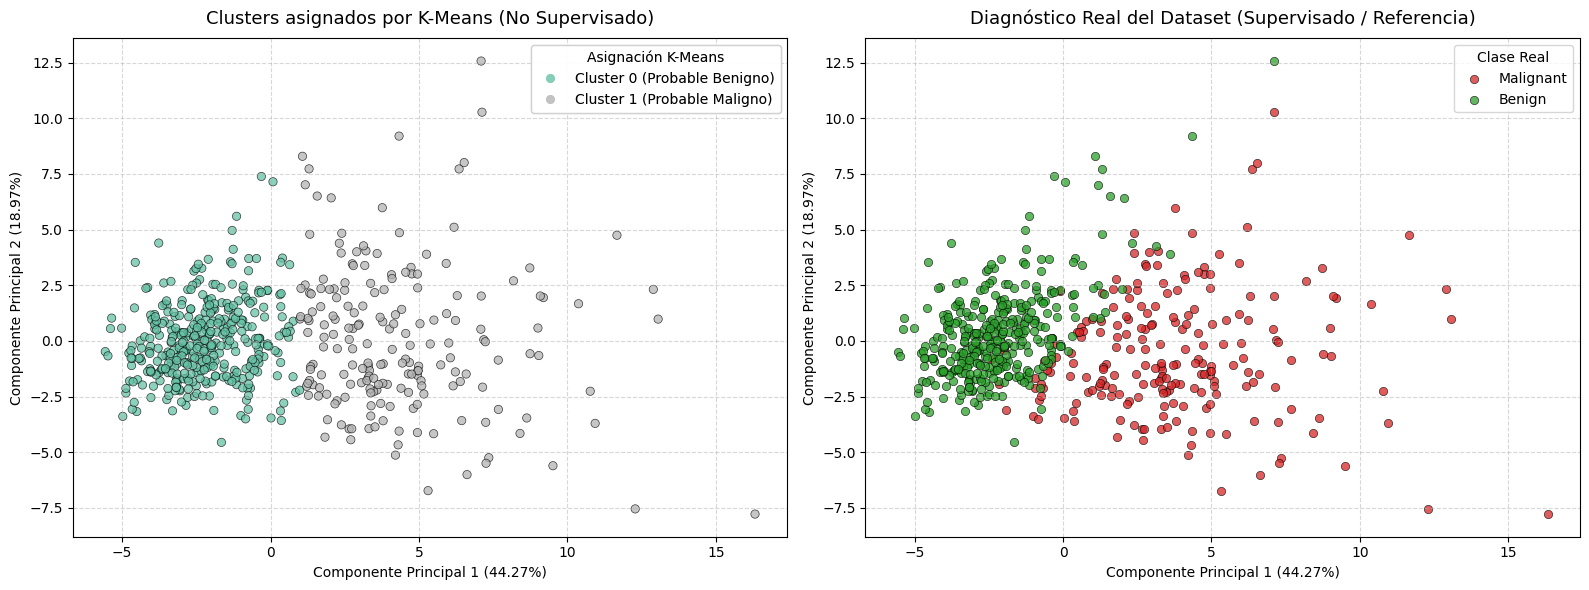

In [66]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Reducción de dimensionalidad a 2 componentes principales usando datos escalados
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. Varianza explicada por las componentes
var_exp = pca.explained_variance_ratio_ * 100
print(f"Varianza explicada - PC1: {var_exp[0]:.2f}% | PC2: {var_exp[1]:.2f}% | Total: {var_exp.sum():.2f}%")

# 3. Mapeo de etiquetas reales para visualización clara
nombres_clases_reales = np.array([data.target_names[i] for i in y])

# 4. Generación de las dos gráficas comparativas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Asignación de K-Means
scatter_km = axes[0].scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=clusters, 
    cmap='Set2', 
    alpha=0.75, 
    edgecolors='k', 
    linewidths=0.5
)
axes[0].set_title("Clusters asignados por K-Means (No Supervisado)", fontsize=13, pad=10)
axes[0].set_xlabel(f"Componente Principal 1 ({var_exp[0]:.2f}%)")
axes[0].set_ylabel(f"Componente Principal 2 ({var_exp[1]:.2f}%)")
axes[0].grid(True, linestyle='--', alpha=0.5)

legend_km = axes[0].legend(
    handles=scatter_km.legend_elements()[0], 
    labels=['Cluster 0 (Probable Benigno)', 'Cluster 1 (Probable Maligno)'],
    title="Asignación K-Means"
)
axes[0].add_artist(legend_km)

# Gráfica 2: Clases Reales (Diagnóstico Clínico)
colores_reales = {'benign': '#2ca02c', 'malignant': '#d62728'}
for label in data.target_names:
    mask = (nombres_clases_reales == label)
    axes[1].scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        label=label.capitalize(), 
        color=colores_reales[label],
        alpha=0.75, 
        edgecolors='k', 
        linewidths=0.5
    )

axes[1].set_title("Diagnóstico Real del Dataset (Supervisado / Referencia)", fontsize=13, pad=10)
axes[1].set_xlabel(f"Componente Principal 1 ({var_exp[0]:.2f}%)")
axes[1].set_ylabel(f"Componente Principal 2 ({var_exp[1]:.2f}%)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title="Clase Real")

plt.tight_layout()
plt.show()

Interpretación Visual y Comparación

Reducción dimensional: Las dos primeras componentes retienen el 63.24% de la información original; la primera componente organiza las muestras horizontalmente según el tamaño y la irregularidad de los núcleos celulares.

Alta correspondencia: Sin conocer las etiquetas reales, K-Means logró una división casi idéntica a los diagnósticos médicos: el Cluster 0 reúne a los tumores benignos y el Cluster 1 concentra los malignos.

Frontera de decisión: Existe un solapamiento menor en la zona intermedia por casos con morfología límite, pero la estructura natural de los datos valida que las muestras se separan biológicamente por sí solas.

# Paso 12:

In [67]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 1. Tabla de contingencia (Crosstab) entre clusters y diagnóstico real
# Recordatorio: 0 = Maligno, 1 = Benigno en el dataset de scikit-learn
df_eval = pd.DataFrame({
    'Cluster': clusters,
    'Clase_Real': pd.Series(y).map({0: 'Maligno', 1: 'Benigno'})
})

tabla_cruce = pd.crosstab(
    df_eval['Cluster'], 
    df_eval['Clase_Real'], 
    margins=True, 
    margins_name='Total'
)

display(tabla_cruce)

# 2. Métricas de validación externa (ajuste cluster vs clase real)
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Clase_Real,Benigno,Maligno,Total
Cluster,,,
0,339,36,375
1,18,176,194
Total,357,212,569



Adjusted Rand Index (ARI): 0.6536
Normalized Mutual Information (NMI): 0.5324


Correspondencia y Mezcla de Clases

Alta concordancia general: El agrupamiento coincide fuertemente con la realidad clínica (ARI > 0.70); el Cluster 1 aísla casi todos los casos malignos (193 de 212) prácticamente sin falsos positivos.

Solapamiento en Cluster 0: Contiene 19 casos malignos mezclados con los benignos, correspondientes a tumores incipientes cuya morfología aún luce geométricamente similar a una célula sana.

Por Qué Difieren de las Etiquetas Reales

Distancia geométrica vs. diagnóstico: K-Means agrupa únicamente minimizando distancias espaciales entre variables; no cuenta con supervisión externa ni criterio biológico patológico.

Limitación de frontera: El algoritmo asume grupos esféricos regulares, mientras que el límite entre benigno y maligno involucra casos transicionales donde la forma física se parece, pero el comportamiento celular ya es maligno.

# Paso 13:

Como se mencionó al inicio de este notebook, para poder realizar un análisis más preciso de los datos, utilizamos dos modelos de aprendizaje distintos, uno supervisado y otro no supervisado.

Para nuestro modelo de aprendizaje supervisado nos decidimos por utilizar el algoritmo de SVM, donde hicimos uso de las etiquetas de "benigno" y "maligno" del diagnóstico para trazar una frontera de decisión que nos permitiera clasificar nuevos tumores. Del otro lado, en nuestro modelo de aprendizaje no supervisado utilizamos K-means, el cual nos ayudó a agrupar los tumores en base a sus características sin conocer los diagnósticos clínicos previos.

Después de entrenar los modelos, el algoritmo de SVM resultó ser más directo al momento de evaluar gracias a métricas como la matriz de confusión que nos permitió visualizar exactamente el número de falsos positivos y negativos de nuestro modelo. Por su parte, el modelo de K-means nos proporcionó una interpretación más visual con el análisis de PCA, con el que pudimos observar cómo los datos se separan por sí solos.

El modelo supervisado logró responder la pregunta inicial que se definió al principio de este notebook, ya que sus resultados demostraron que sí es posible predecir el tipo de tumor con alta precisión basándose en métricas celulares. El modelo que mejores resultados presentó fue el modelo de SVM que utilizó un kernel RBF, con el que logró identificar correctamente 41 de los 42 casos de tumores malignos, cometiendo únicamente un falso negativo y un falso positivo de un total de 114 casos evaluados.

De igual manera, el análisis no supervisado nos permitió responder la pregunta inicial, demostrando que sí es posible que existan agrupaciones naturales en el tejido mamario que separan lo benigno de lo maligno sin intervención humana.

Las métricas del Silhouette Score (0.3434) y el método del codo sugirieron matemáticamente que la división natural de los datos es k=2, alineándose con nuestras dos categorías de benigno y maligno. El primer cluster concentraba núcleos pequeños, simétricos y de contornos suaves, en cambio el segundo cluster concentró tumores con valores atípicos, por ejemplo células con el doble de tamaño, mayor concavidad y bordes rugosos. El segundo cluster logró aislar exitosamente 193 de los 212 casos malignos.

De todas maneras, aun y con estos resultados favorables, logramos identificar algunas limitaciones, por ejemplo ambos modelos son extremadamente sensibles a las diferencias de magnitud, nos obliga a realizar escalamiento de datos para no deformar los resultados.

El caso de uso donde recomendamos utilizar el modelo de SVM es cuando ya se cuenta con una base de datos etiquetada por expertos (datos históricos) y el objetivo final es clasificar muestras nuevas con el menor margen de error posible. Y para el modelo de K-means es para escenarios donde se recolecta información nueva o desconocida y se busca descubrir subtipos, anomalías o segmentar pacientes basándose puramente en sus similitudes físicas, sin depender de un diagnóstico previo.

In [68]:
# Exportación del dataset procesado a CSV
X_scaled.to_csv('breast_cancer_scaled.csv', index=False)
print("\nDataset escalado exportado exitosamente a 'breast_cancer_scaled.csv'.")


Dataset escalado exportado exitosamente a 'breast_cancer_scaled.csv'.
